In [1]:
# dependencies

from Bio import AlignIO
from Bio import SeqIO
import re
import pandas as pd
from ete3 import NCBITaxa
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import ast

In [2]:
# results in FASTA form into dataframe

def pfam_results(results_input):
    data = {'accession': [], 'taxon': [], 'seq identifier': [], 'I Helix': []}
    with open(results_input) as fp:
        for record in SeqIO.parse(fp, "fasta"):
            seqident = re.findall(r"\|(?P<sequence_id>\w+)\|", record.id)
            accession = record.description
            taxon = re.findall(r"OX=(\d+)", record.description)
            sequence = str(record.seq)

            # attaching to dictionary
            data['seq identifier'].append(", ".join(seqident))
            data['accession'].append(accession)
            data['taxon'].append(", ".join(taxon))
            data['I Helix'].append(sequence)

    df = pd.DataFrame.from_dict(data)
    return df

In [3]:
# Converting HMM search output for pfam data to FASTA file
input = '/home/alecia/chapter3-repo/output/hmm_search_2/pfam/3/ihelixhits_e_0p001_z__T_.aln'
outfile_fasta = '/home/alecia/chapter3-repo/output/hmm_search_2/pfam/3/ihelixhits_e_0p001_z__T_.fasta'

with open(input) as infile:
    alignment = AlignIO.read(infile, 'stockholm')

SeqIO.write(alignment, outfile_fasta, 'fasta')

278757

In [4]:
pfam_r1 = pfam_results('/home/alecia/chapter3-repo/output/hmm_search_1/pfam/3/ihelixhits_e_0p001_z__T_.fasta')
pfam_r2 = pfam_results('/home/alecia/chapter3-repo/output/hmm_search_2/pfam/3/ihelixhits_e_0p001_z__T_.fasta')

In [5]:
pfam_r1

,accession,taxon,seq identifier,I Helix
0,tr|A0A498MRP4|A0A498MRP4_LABRO/720-751 [subseq...,84645,A0A498MRP4,-DGLVIACL-DV-I-EA--G---TET--T--A-T--TLR-WGLLFMIKY
1,tr|A0A498MRP4|A0A498MRP4_LABRO/1166-1197 [subs...,84645,A0A498MRP4,-EGLVISCL-DV-I-EA--G---TET--T--A-T--TLR-WGLLFMIKY
2,tr|A0A498MRP4|A0A498MRP4_LABRO/1618-1649 [subs...,84645,A0A498MRP4,-DGLVIICL-DV-I-EA--G---TET--T--T-T--TLR-WGLLFMIKY
3,tr|A0A498MRP4|A0A498MRP4_LABRO/2174-2205 [subs...,84645,A0A498MRP4,-DGLVISCL-DV-I-EA--G---TET--T--A-T--TLR-WGLLFMIKY
4,tr|A0A498MRP4|A0A498MRP4_LABRO/2626-2657 [subs...,84645,A0A498MRP4,-DGLVISCL-DV-I-EA--G---SET--T--A-T--TLR-WGLLFMIKY
...,...,...,...,...
162079,tr|A0A2S3GQM6|A0A2S3GQM6_9POAL/311-340 [subseq...,206008,A0A2S3GQM6,---LRDFCI-SF-V-LA--G---RDT--S--S-V--ALA-WFFWLLASH
162080,tr|A0A8X7P7K3|A0A8X7P7K3_BRACI/295-322 [subseq...,52824,A0A8X7P7K3,-----RECK-LF-Y-FA--G---QET--T--S-V--LLV-WTMILLSHH
162081,tr|A0A7S8A7J9|A0A7S8A7J9_9BRAD/226-256 [subseq...,1325114,A0A7S8A7J9,-DEMVSMVF-LL-L-AA--G---SET--T--T-H--LIS-GSAYELLR-
162082,tr|A0A395IRT2|A0A395IRT2_9HELO/207-235 [subseq...,38457,A0A395IRT2,---ILANMI-TF-L-IA--G---HET--I--S-G--ILS-FVFLNLMK-


In [7]:
pfam_r2

,accession,taxon,seq identifier,I Helix
0,tr|A0A182XW67|A0A182XW67_ANOST/287-321 [subseq...,30069,A0A182XW67,LDMTQV--AGQCY-S-F-F-I--A----G------FE--T-SAS--...
1,tr|A0A182XW67|A0A182XW67_ANOST/819-853 [subseq...,30069,A0A182XW67,MTLNEL--AAQVF-I-F-F-L--A----G------FE--T-SST--...
2,tr|A0A182XW67|A0A182XW67_ANOST/1316-1351 [subs...,30069,A0A182XW67,LTMNEL--AAQVF-I-F-F-V--A----G------FE--T-SST--...
3,tr|A0A182XW67|A0A182XW67_ANOST/1825-1860 [subs...,30069,A0A182XW67,LTLNEL--AAQVF-V-F-F-L--A----G------FE--T-SST--...
4,tr|A0A182XW67|A0A182XW67_ANOST/2334-2369 [subs...,30069,A0A182XW67,LTHNEL--AAQVL-I-F-F-L--A----G------FE--T-SST--...
...,...,...,...,...
278752,tr|A0A1Y2UC39|A0A1Y2UC39_9PEZI/289-316 [subseq...,1001938,A0A1Y2UC39,---------MEAI-L-F-T-V--A----G------GD--T-TST--...
278753,tr|A0A1H4E4S6|A0A1H4E4S6_9BURK/238-270 [subseq...,83784,A0A1H4E4S6,LSEVEL--LQNCI-F-I-L-N--A----G------HE--T-TTN--...
278754,tr|A0A0E4FSG9|A0A0E4FSG9_9BRAD/239-274 [subseq...,1355477,A0A0E4FSG9,LSDAEL--ISMLW-G-M-L-L--G----G------FV--T-TAA--...
278755,tr|A0A210Q976|A0A210Q976_MIZYE/289-323 [subseq...,6573,A0A210Q976,FTDNNL--TTLIG-N-V-F-S--A----G------TE--T-TAT--...


In [6]:
r1r2_merged_pfam = (pd.merge(pfam_r1, pfam_r2, how='outer', on=['seq identifier', 'taxon'])
                    .fillna(0)
                    .drop_duplicates(subset=['seq identifier']))
r1r2_merged_pfam

,accession_x,taxon,seq identifier,I Helix_x,accession_y,I Helix_y
0,tr|A0A010Q4L3|A0A010Q4L3_9PEZI/178-209 [subseq...,1445577,A0A010Q4L3,-EAIVHNII-TF-L-VA--G---HET--T--S-G--LLS-FAIYYLVEH,tr|A0A010Q4L3|A0A010Q4L3_9PEZI/175-210 [subseq...,LSEEAI--VHNII-T-F-L-V--A----G------HE--T-TSG--...
1,0,1445577,A0A010Q5H6,0,tr|A0A010Q5H6|A0A010Q5H6_9PEZI/329-359 [subseq...,---ETM--RAESA-G-F-V-V--A----G------HD--T-TST--...
2,tr|A0A010Q6U4|A0A010Q6U4_9PEZI/328-354 [subseq...,1445577,A0A010Q6U4,------QLK-IF-M-FA--G---HDT--T--A-T--ALC-WAIHCIAKN,tr|A0A010Q6U4|A0A010Q6U4_9PEZI/323-355 [subseq...,---ETV--VSQLK-I-F-M-F--A----G------HD--T-TAT--...
3,0,1445577,A0A010Q6V4,0,tr|A0A010Q6V4|A0A010Q6V4_9PEZI/275-301 [subseq...,---------AECL-D-H-I-G--A----G------IE--T-TGD--...
4,0,1445577,A0A010Q949,0,tr|A0A010Q949|A0A010Q949_9PEZI/336-368 [subseq...,---EQL--VDHVM-T-F-L-T--A----G------HE--S-TAT--...
...,...,...,...,...,...,...
294301,0,1086054,X8JTW5,0,tr|X8JTW5|X8JTW5_9AGAM/309-343 [subseq from] C...,-SDHEM--AMVVL-S-F-L-F--A----S------QD--A-MSS--...
294302,0,1086054,X8JU90,0,tr|X8JU90|X8JU90_9AGAM/314-349 [subseq from] C...,ISEEEM--LGQLN-T-L-I-F--A----G------HD--T-TSG--...
294303,tr|X8JXB4|X8JXB4_9AGAM/332-363 [subseq from] C...,1086054,X8JXB4,-DQLLGQMN-TL-I-FA--G---HET--T--S-G--ALS-RILHLLAMN,tr|X8JXB4|X8JXB4_9AGAM/329-363 [subseq from] C...,LPEDQL--LGQMN-T-L-I-F--A----G------HE--T-TSG--...
294304,tr|Z9JM62|Z9JM62_9GAMM/225-257 [subseq from] C...,1444770,Z9JM62,HDEIVSNVI-LL-L-IA--G---YET--T--S-N--MIG-NALIALHRH,tr|Z9JM62|Z9JM62_9GAMM/223-258 [subseq from] C...,LTHDEI--VSNVI-L-L-L-I--A----G------YE--T-TSN--...


In [7]:
# If sequence in I_Helix y, take the acid alcohol - if not, take the acid alcohol in I Helix x
# Take out consensus sequence of the oxygen binding groove as well

result_data_acidalc = []

for index, row in r1r2_merged_pfam.iterrows():
    if row['I Helix_y'] != 0:
        acid = row['I Helix_y'][36]
        alc = row['I Helix_y'][39]
    else:
        acid = row['I Helix_x'][24]
        alc = row['I Helix_x'][25]

    if row['I Helix_y'] != 0:
        consensus = row['I Helix_y'][23:42]
    else:
        consensus = row['I Helix_x'][16:29]

    # Append a dictionary with relevant information to the result_data list
    result_data_acidalc.append({
        'accession': row['accession_y'],
        'sequence_y': row['I Helix_y'],
        'sequence_x': row['I Helix_x'],
        'seq identifier': row['seq identifier'],
        'acid': acid,
        'alc': alc,
        'consensus': consensus,
        'taxon': row['taxon'],
    })


# Create a DataFrame from the result_data list
result_df_2 = pd.DataFrame(result_data_acidalc)


In [8]:
result_df_2

,accession,sequence_y,sequence_x,seq identifier,acid,alc,consensus,taxon
0,tr|A0A010Q4L3|A0A010Q4L3_9PEZI/175-210 [subseq...,LSEEAI--VHNII-T-F-L-V--A----G------HE--T-TSG--...,-EAIVHNII-TF-L-VA--G---HET--T--S-G--LLS-FAIYYLVEH,A0A010Q4L3,E,T,A----G------HE--T-T,1445577
1,tr|A0A010Q5H6|A0A010Q5H6_9PEZI/329-359 [subseq...,---ETM--RAESA-G-F-V-V--A----G------HD--T-TST--...,0,A0A010Q5H6,D,T,A----G------HD--T-T,1445577
2,tr|A0A010Q6U4|A0A010Q6U4_9PEZI/323-355 [subseq...,---ETV--VSQLK-I-F-M-F--A----G------HD--T-TAT--...,------QLK-IF-M-FA--G---HDT--T--A-T--ALC-WAIHCIAKN,A0A010Q6U4,D,T,A----G------HD--T-T,1445577
3,tr|A0A010Q6V4|A0A010Q6V4_9PEZI/275-301 [subseq...,---------AECL-D-H-I-G--A----G------IE--T-TGD--...,0,A0A010Q6V4,E,T,A----G------IE--T-T,1445577
4,tr|A0A010Q949|A0A010Q949_9PEZI/336-368 [subseq...,---EQL--VDHVM-T-F-L-T--A----G------HE--S-TAT--...,0,A0A010Q949,E,S,A----G------HE--S-T,1445577
...,...,...,...,...,...,...,...,...
287225,tr|X8JTW5|X8JTW5_9AGAM/309-343 [subseq from] C...,-SDHEM--AMVVL-S-F-L-F--A----S------QD--A-MSS--...,0,X8JTW5,D,A,A----S------QD--A-M,1086054
287226,tr|X8JU90|X8JU90_9AGAM/314-349 [subseq from] C...,ISEEEM--LGQLN-T-L-I-F--A----G------HD--T-TSG--...,0,X8JU90,D,T,A----G------HD--T-T,1086054
287227,tr|X8JXB4|X8JXB4_9AGAM/329-363 [subseq from] C...,LPEDQL--LGQMN-T-L-I-F--A----G------HE--T-TSG--...,-DQLLGQMN-TL-I-FA--G---HET--T--S-G--ALS-RILHLLAMN,X8JXB4,E,T,A----G------HE--T-T,1086054
287228,tr|Z9JM62|Z9JM62_9GAMM/223-258 [subseq from] C...,LTHDEI--VSNVI-L-L-L-I--A----G------YE--T-TSN--...,HDEIVSNVI-LL-L-IA--G---YET--T--S-N--MIG-NALIALHRH,Z9JM62,E,T,A----G------YE--T-T,1444770


In [9]:
result_df_2['consensus'] = result_df_2['consensus'].str.replace(r'-', '', regex=True)

In [10]:
result_df_2

,accession,sequence_y,sequence_x,seq identifier,acid,alc,consensus,taxon
0,tr|A0A010Q4L3|A0A010Q4L3_9PEZI/175-210 [subseq...,LSEEAI--VHNII-T-F-L-V--A----G------HE--T-TSG--...,-EAIVHNII-TF-L-VA--G---HET--T--S-G--LLS-FAIYYLVEH,A0A010Q4L3,E,T,AGHETT,1445577
1,tr|A0A010Q5H6|A0A010Q5H6_9PEZI/329-359 [subseq...,---ETM--RAESA-G-F-V-V--A----G------HD--T-TST--...,0,A0A010Q5H6,D,T,AGHDTT,1445577
2,tr|A0A010Q6U4|A0A010Q6U4_9PEZI/323-355 [subseq...,---ETV--VSQLK-I-F-M-F--A----G------HD--T-TAT--...,------QLK-IF-M-FA--G---HDT--T--A-T--ALC-WAIHCIAKN,A0A010Q6U4,D,T,AGHDTT,1445577
3,tr|A0A010Q6V4|A0A010Q6V4_9PEZI/275-301 [subseq...,---------AECL-D-H-I-G--A----G------IE--T-TGD--...,0,A0A010Q6V4,E,T,AGIETT,1445577
4,tr|A0A010Q949|A0A010Q949_9PEZI/336-368 [subseq...,---EQL--VDHVM-T-F-L-T--A----G------HE--S-TAT--...,0,A0A010Q949,E,S,AGHEST,1445577
...,...,...,...,...,...,...,...,...
287225,tr|X8JTW5|X8JTW5_9AGAM/309-343 [subseq from] C...,-SDHEM--AMVVL-S-F-L-F--A----S------QD--A-MSS--...,0,X8JTW5,D,A,ASQDAM,1086054
287226,tr|X8JU90|X8JU90_9AGAM/314-349 [subseq from] C...,ISEEEM--LGQLN-T-L-I-F--A----G------HD--T-TSG--...,0,X8JU90,D,T,AGHDTT,1086054
287227,tr|X8JXB4|X8JXB4_9AGAM/329-363 [subseq from] C...,LPEDQL--LGQMN-T-L-I-F--A----G------HE--T-TSG--...,-DQLLGQMN-TL-I-FA--G---HET--T--S-G--ALS-RILHLLAMN,X8JXB4,E,T,AGHETT,1086054
287228,tr|Z9JM62|Z9JM62_9GAMM/223-258 [subseq from] C...,LTHDEI--VSNVI-L-L-L-I--A----G------YE--T-TSN--...,HDEIVSNVI-LL-L-IA--G---YET--T--S-N--MIG-NALIALHRH,Z9JM62,E,T,AGYETT,1444770


In [11]:
ncbi = NCBITaxa()

In [12]:
# Function to fetch lineage and ranks using NCBITaxa
def get_lineage_and_ranks(taxon_id):
    try:
        lineage = ncbi.get_lineage(taxon_id)  # List of lineage taxids
        ranks = ncbi.get_rank(lineage)  # Get ranks for the lineage
        
        # Map the taxid to its corresponding name and rank
        lineage_and_ranks = {ncbi.get_taxid_translator([taxid])[taxid]: ranks[taxid] 
                             for taxid in lineage if taxid in ranks}
        
        return lineage_and_ranks
    except:
        return None  # Return None if the ID is not found or there is an error

In [13]:
# Apply ncbi taxa to dataframe in chunks to access lineage and ranks

result_df_2["lineage_and_ranks"] = result_df_2["taxon"].apply(lambda x: get_lineage_and_ranks(int(x)) if pd.notna(x) else None)

/home/alecia/anaconda3/envs/IHelix/lib/python3.12/site-packages/ete3/ncbi_taxonomy/ncbiquery.py:243: UserWarning: taxid 914237 was translated into 2792576
  warnings.warn("taxid %s was translated into %s" %(taxid, merged_conversion[taxid]))
/home/alecia/anaconda3/envs/IHelix/lib/python3.12/site-packages/ete3/ncbi_taxonomy/ncbiquery.py:243: UserWarning: taxid 553056 was translated into 3097545
  warnings.warn("taxid %s was translated into %s" %(taxid, merged_conversion[taxid]))
/home/alecia/anaconda3/envs/IHelix/lib/python3.12/site-packages/ete3/ncbi_taxonomy/ncbiquery.py:243: UserWarning: taxid 1276135 was translated into 3151832
  warnings.warn("taxid %s was translated into %s" %(taxid, merged_conversion[taxid]))
/home/alecia/anaconda3/envs/IHelix/lib/python3.12/site-packages/ete3/ncbi_taxonomy/ncbiquery.py:243: UserWarning: taxid 686832 was translated into 76867
  warnings.warn("taxid %s was translated into %s" %(taxid, merged_conversion[taxid]))
/home/alecia/anaconda3/envs/IHelix/li

In [14]:
result_df_2.to_csv('r1r2_pfam_acidalc_taxon.csv')

In [15]:
input = '/home/alecia/chapter3-repo/analysis/pfam_tax/r1r2_pfam_acidalc_taxon.csv'

with open(input) as f:
    pfam_with_taxa = pd.read_csv(input)

pfam_with_taxa

,Unnamed: 0,accession,sequence_y,sequence_x,seq identifier,acid,alc,consensus,taxon,lineage_and_ranks
0,0,tr|A0A010Q4L3|A0A010Q4L3_9PEZI/175-210 [subseq...,LSEEAI--VHNII-T-F-L-V--A----G------HE--T-TSG--...,-EAIVHNII-TF-L-VA--G---HET--T--S-G--LLS-FAIYYLVEH,A0A010Q4L3,E,T,AGHETT,1445577,"{'root': 'no rank', 'cellular organisms': 'no ..."
1,1,tr|A0A010Q5H6|A0A010Q5H6_9PEZI/329-359 [subseq...,---ETM--RAESA-G-F-V-V--A----G------HD--T-TST--...,0,A0A010Q5H6,D,T,AGHDTT,1445577,"{'root': 'no rank', 'cellular organisms': 'no ..."
2,2,tr|A0A010Q6U4|A0A010Q6U4_9PEZI/323-355 [subseq...,---ETV--VSQLK-I-F-M-F--A----G------HD--T-TAT--...,------QLK-IF-M-FA--G---HDT--T--A-T--ALC-WAIHCIAKN,A0A010Q6U4,D,T,AGHDTT,1445577,"{'root': 'no rank', 'cellular organisms': 'no ..."
3,3,tr|A0A010Q6V4|A0A010Q6V4_9PEZI/275-301 [subseq...,---------AECL-D-H-I-G--A----G------IE--T-TGD--...,0,A0A010Q6V4,E,T,AGIETT,1445577,"{'root': 'no rank', 'cellular organisms': 'no ..."
4,4,tr|A0A010Q949|A0A010Q949_9PEZI/336-368 [subseq...,---EQL--VDHVM-T-F-L-T--A----G------HE--S-TAT--...,0,A0A010Q949,E,S,AGHEST,1445577,"{'root': 'no rank', 'cellular organisms': 'no ..."
...,...,...,...,...,...,...,...,...,...,...
287225,287225,tr|X8JTW5|X8JTW5_9AGAM/309-343 [subseq from] C...,-SDHEM--AMVVL-S-F-L-F--A----S------QD--A-MSS--...,0,X8JTW5,D,A,ASQDAM,1086054,"{'root': 'no rank', 'cellular organisms': 'no ..."
287226,287226,tr|X8JU90|X8JU90_9AGAM/314-349 [subseq from] C...,ISEEEM--LGQLN-T-L-I-F--A----G------HD--T-TSG--...,0,X8JU90,D,T,AGHDTT,1086054,"{'root': 'no rank', 'cellular organisms': 'no ..."
287227,287227,tr|X8JXB4|X8JXB4_9AGAM/329-363 [subseq from] C...,LPEDQL--LGQMN-T-L-I-F--A----G------HE--T-TSG--...,-DQLLGQMN-TL-I-FA--G---HET--T--S-G--ALS-RILHLLAMN,X8JXB4,E,T,AGHETT,1086054,"{'root': 'no rank', 'cellular organisms': 'no ..."
287228,287228,tr|Z9JM62|Z9JM62_9GAMM/223-258 [subseq from] C...,LTHDEI--VSNVI-L-L-L-I--A----G------YE--T-TSN--...,HDEIVSNVI-LL-L-IA--G---YET--T--S-N--MIG-NALIALHRH,Z9JM62,E,T,AGYETT,1444770,"{'root': 'no rank', 'cellular organisms': 'no ..."


In [16]:
# Define standard taxonomic ranks
tax_ranks = ['kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species']

# Function to flip dict and extract ranks
def extract_taxonomy(tax_str):
    try:
        # Parse only if it's a string
        tax_dict = ast.literal_eval(tax_str) if isinstance(tax_str, str) else tax_str
        # Flip key-values: {'Metazoa': 'kingdom'} → {'kingdom': 'Metazoa'}
        flipped = {v.strip(): k.strip() for k, v in tax_dict.items()}
        # Extract ranks in the desired order
        return [flipped.get(rank, None) for rank in tax_ranks]
    except Exception as e:
        print(f"Error parsing: {tax_str}\n{e}")  # Debugging info
        return [None] * len(tax_ranks)

# Apply extraction function
pfam_with_taxa[tax_ranks] = pfam_with_taxa['lineage_and_ranks'].apply(lambda x: pd.Series(extract_taxonomy(x)))

# Save or view the result
pfam_with_taxa.to_csv('taxonomy_parsed.csv', index=False)
print(pfam_with_taxa.head())

   Unnamed: 0                                          accession  \
0           0  tr|A0A010Q4L3|A0A010Q4L3_9PEZI/175-210 [subseq...   
1           1  tr|A0A010Q5H6|A0A010Q5H6_9PEZI/329-359 [subseq...   
2           2  tr|A0A010Q6U4|A0A010Q6U4_9PEZI/323-355 [subseq...   
3           3  tr|A0A010Q6V4|A0A010Q6V4_9PEZI/275-301 [subseq...   
4           4  tr|A0A010Q949|A0A010Q949_9PEZI/336-368 [subseq...   

                                          sequence_y  \
0  LSEEAI--VHNII-T-F-L-V--A----G------HE--T-TSG--...   
1  ---ETM--RAESA-G-F-V-V--A----G------HD--T-TST--...   
2  ---ETV--VSQLK-I-F-M-F--A----G------HD--T-TAT--...   
3  ---------AECL-D-H-I-G--A----G------IE--T-TGD--...   
4  ---EQL--VDHVM-T-F-L-T--A----G------HE--S-TAT--...   

                                          sequence_x seq identifier acid alc  \
0  -EAIVHNII-TF-L-VA--G---HET--T--S-G--LLS-FAIYYLVEH     A0A010Q4L3    E   T   
1                                                  0     A0A010Q5H6    D   T   
2  ------QLK-I

In [17]:
pfam_with_taxa['acid_alc'] = pfam_with_taxa['acid'] + pfam_with_taxa['alc']

In [19]:
pfam_with_taxa.to_csv('fulltable.csv', index=False)

In [21]:
kingdom_pair_df = pfam_with_taxa.groupby(['acid_alc', 'kingdom']).size().reset_index(name='count')
kingdom_consensus_df = pfam_with_taxa.groupby(['consensus', 'kingdom']).size().reset_index(name='count')


In [22]:
kingdom_pair_df.head()

,acid_alc,kingdom,count
0,-T,Fungi,1
1,AA,Bacillati,1
2,AA,Fungi,2
3,AA,Metazoa,3
4,AA,Pseudomonadati,5


In [23]:
total_acidalc_counts = pfam_with_taxa['acid_alc'].value_counts().reset_index()
total_acidalc_counts.columns = ['acid_alc', 'total_count']

total_consensus_counts = pfam_with_taxa['consensus'].value_counts().reset_index()
total_consensus_counts.columns = ['consensus', 'total_count']

In [24]:
total_consensus_counts

,consensus,total_count
0,AGHETT,40196
1,AGTETT,11364
2,AGSDTT,10317
3,AGTDTT,10176
4,AGRDTT,10110
...,...,...
4593,VAFDTI,1
4594,VGHDSA,1
4595,AARDNV,1
4596,SGHEAT,1


In [25]:
result_acidalc = pd.merge(kingdom_pair_df, total_acidalc_counts, on='acid_alc')
result_acidalc.to_csv('acidalc_kingdom.csv')

# manually removed -T from csv

In [26]:
result_consensus = pd.merge(kingdom_consensus_df, total_consensus_counts, on='consensus')
result_consensus.to_csv('consensus_kingdom.csv')

# manually removed -T from csv

In [27]:
acidalc_clean = pd.read_csv('acidalc_kingdom.csv')
consensus_clean = pd.read_csv('consensus_kingdom.csv')

In [28]:
groupedacidalc_totalcount = (acidalc_clean.sort_values(by='total_count', ascending=False)
         .reset_index()
)
groupedconsensus_totalcount = (consensus_clean.sort_values(by='total_count', ascending=False)
         .reset_index()
)

groupedconsensus_totalcount

,index,Unnamed: 0,consensus,kingdom,count,total_count
0,1414,1414,AGHETT,Metazoa,1033,40196
1,1417,1417,AGHETT,Thermoproteati,22,40196
2,1418,1418,AGHETT,Thermotogati,97,40196
3,1413,1413,AGHETT,Fungi,8201,40196
4,1419,1419,AGHETT,Viridiplantae,2576,40196
...,...,...,...,...,...,...
7039,29,29,AAEETT,Bacillati,1,1
7040,7008,7008,VGYLTT,Metazoa,1,1
7041,7010,7010,VGYPTT,Bacillati,1,1
7042,7011,7011,VGYVST,Metazoa,1,1


In [29]:
cols = ['count', 'total_count']
groupedconsensus_totalcount[cols] = groupedconsensus_totalcount[cols].apply(
    pd.to_numeric, errors='coerce'
)

In [30]:
cols = ['count', 'total_count']
groupedacidalc_totalcount[cols] = groupedacidalc_totalcount[cols].apply(
    pd.to_numeric, errors='coerce'
)

In [31]:
groupedconsensus_totalcount['percentage'] = groupedconsensus_totalcount['count'] / groupedconsensus_totalcount['total_count'] * 100

In [32]:
groupedacidalc_totalcount['percentage'] = groupedacidalc_totalcount['count'] / groupedacidalc_totalcount['total_count'] * 100

In [33]:
groupedconsensus_totalcount.sort_values(by='total_count', ascending=False)
groupedconsensus_totalcount = groupedconsensus_totalcount.drop('Unnamed: 0', axis=1)
groupedconsensus_totalcount = groupedconsensus_totalcount.drop('index', axis=1)

In [34]:
groupedacidalc_totalcount.sort_values(by='total_count', ascending=False)
groupedacidalc_totalcount = groupedacidalc_totalcount.drop('Unnamed: 0', axis=1)
groupedacidalc_totalcount = groupedacidalc_totalcount.drop('index', axis=1)

In [37]:
groupedconsensus_totalcount

,consensus,kingdom,count,total_count,percentage
0,AGHETT,Metazoa,1033,40196,2.569907
1,AGHETT,Thermoproteati,22,40196,0.054732
2,AGHETT,Thermotogati,97,40196,0.241318
3,AGHETT,Fungi,8201,40196,20.402528
4,AGHETT,Viridiplantae,2576,40196,6.408598
...,...,...,...,...,...
7039,AAEETT,Bacillati,1,1,100.000000
7040,VGYLTT,Metazoa,1,1,100.000000
7041,VGYPTT,Bacillati,1,1,100.000000
7042,VGYVST,Metazoa,1,1,100.000000


In [38]:
pattern = re.compile(r"[AG]G.[ED]TT")
groupedconsensus_totalcount["I_helix_consensus"] = groupedconsensus_totalcount["consensus"].apply(lambda seq: "yes" if pattern.search(seq) else "no")

In [39]:
groupedconsensus_totalcount

,consensus,kingdom,count,total_count,percentage,I_helix_consensus
0,AGHETT,Metazoa,1033,40196,2.569907,yes
1,AGHETT,Thermoproteati,22,40196,0.054732,yes
2,AGHETT,Thermotogati,97,40196,0.241318,yes
3,AGHETT,Fungi,8201,40196,20.402528,yes
4,AGHETT,Viridiplantae,2576,40196,6.408598,yes
...,...,...,...,...,...,...
7039,AAEETT,Bacillati,1,1,100.000000,no
7040,VGYLTT,Metazoa,1,1,100.000000,no
7041,VGYPTT,Bacillati,1,1,100.000000,no
7042,VGYVST,Metazoa,1,1,100.000000,no


In [36]:
groupedacidalc_totalcount

,acid_alc,kingdom,count,total_count,percentage
0,ET,Bacillati,38444,134906,28.496879
1,ET,Bamfordvirae,3,134906,0.002224
2,ET,Fungi,21027,134906,15.586408
3,ET,Heunggongvirae,2,134906,0.001483
4,ET,Methanobacteriati,494,134906,0.366181
...,...,...,...,...,...
420,EX,Bacillati,1,1,100.000000
421,FS,Metazoa,1,1,100.000000
422,EC,Bacillati,1,1,100.000000
423,AF,Viridiplantae,1,1,100.000000


In [40]:
groupedconsensus_totalcount.to_csv('consensus_and_taxa_counts_for_r.csv')
groupedacidalc_totalcount.to_csv('acidalc_and_taxa_counts_for_r.csv')

In [ ]:
## The rest is failed attempts at making graphs

# Final code is all above ^^^^

In [76]:
data = {
    1: [1, 2, 235], 
    2: [52, 53, 4], 
    3: [45, 65, 74], 
    4: [23, 453, 34]
}
index = ['A', 'B', 'C']

In [47]:
df = pd.DataFrame(data, index=index)
df.columns.name = "Bin"  # Name the column index
df.index.name = "Category"  # Name the row index
df

df_long = df.reset_index().melt(id_vars=["acid_alc"], var_name="kingdom", value_name="Count")
df_long

KeyError: "The following 'id_vars' are not present in the DataFrame: ['acid_alc']"

<Axes: xlabel='Count', ylabel='Category'>

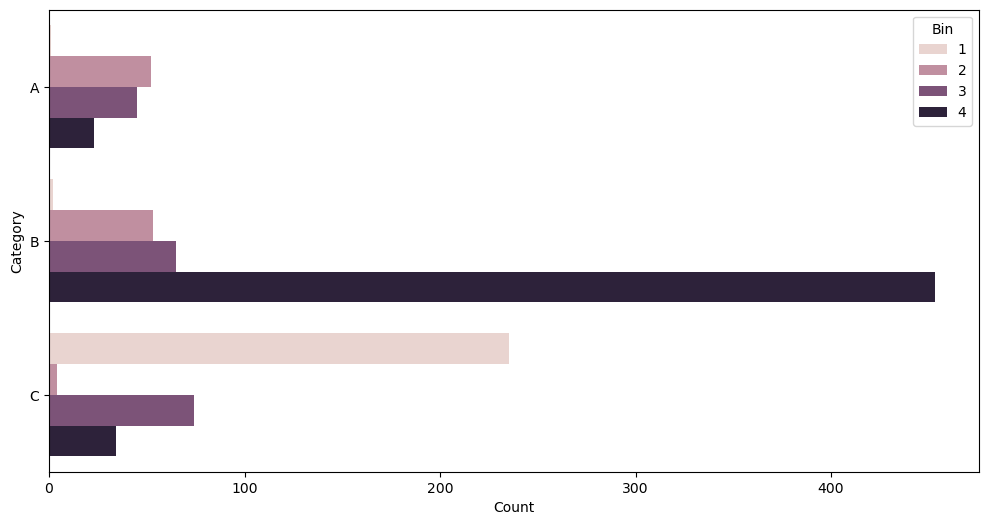

In [46]:
# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x="Count", y="Category", hue="Bin", data=df_long, orient="h")

In [26]:
df_pivot = final.pivot_table(index='acid_alc', columns='kingdom', values='percentage', aggfunc='sum')

In [37]:
df_pivot.fillna(0)

kingdom,Bacillati,Bamfordvirae,Fungi,Heunggongvirae,Metazoa,Methanobacteriati,Nanobdellati,Pseudomonadati,Thermoproteati,Thermotogati,Viridiplantae
acid_alc,,,,,,,,,,,
AA,7.142857,0.0,11.764706,0.0,15.000000,0.0,0.0,20.833333,0.0,0.0,0.000000
AF,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,9.090909
AL,7.692308,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000
AN,0.923077,0.0,0.000000,0.0,48.571429,0.0,0.0,0.000000,0.0,0.0,0.000000
AP,0.000000,0.0,0.000000,0.0,9.090909,0.0,0.0,0.000000,0.0,0.0,4.347826
...,...,...,...,...,...,...,...,...,...,...,...
YN,0.000000,0.0,0.833333,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.119617
YP,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.120337
YQ,0.000000,0.0,0.120048,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000


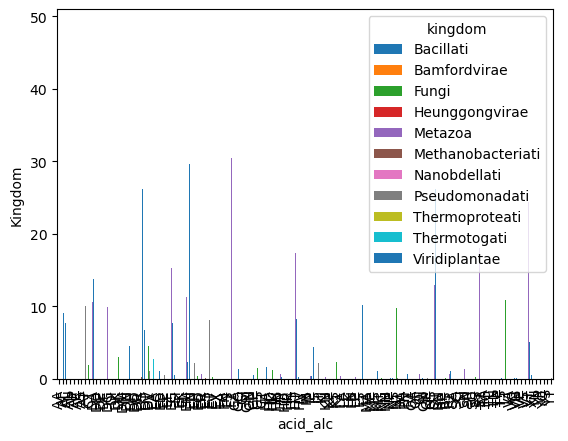

In [ ]:
ax = df_pivot.plot(kind='bar', ylabel='Kingdom')

In [28]:
df_normalized = (df_pivot.div(df_pivot.sum(axis=1), axis=0)
                 .fillna(0))

In [29]:
df_normalized.to_csv('pfam_r1r2_acidalc_normalisedforplot.csv')

In [50]:
df_normalized

kingdom,Bacillati,Bamfordvirae,Fungi,Heunggongvirae,Metazoa,Methanobacteriati,Nanobdellati,Pseudomonadati,Thermoproteati,Thermotogati,Viridiplantae
acid_alc,,,,,,,,,,,
AA,0.130485,0.0,0.214916,0.0,0.274018,0.0,0.0,0.380581,0.0,0.0,0.000000
AF,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,1.000000
AL,1.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000
AN,0.018650,0.0,0.000000,0.0,0.981350,0.0,0.0,0.000000,0.0,0.0,0.000000
AP,0.000000,0.0,0.000000,0.0,0.676471,0.0,0.0,0.000000,0.0,0.0,0.323529
...,...,...,...,...,...,...,...,...,...,...,...
YN,0.000000,0.0,0.874477,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.125523
YP,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,1.000000
YQ,0.000000,0.0,1.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000


In [30]:
As_first = pd.read_csv('/home/alecia/chapter3-repo/analysis/pfam_r1r2_comparison/pfam_r1r2_acidalc_As_First.csv')
As_index = As_first.set_index('acid_alc')

In [32]:
final['kingdom'].unique()

array(['Bamfordvirae', 'Thermoproteati', 'Bacillati', 'Pseudomonadati',
       'Nanobdellati', 'Heunggongvirae', 'Fungi', 'Viridiplantae',
       'Thermotogati', 'Metazoa', 'Methanobacteriati'], dtype=object)

In [33]:
count = (pd.read_csv('/home/alecia/chapter3-repo/analysis/pfam_r1r2_comparison/pfam_r1r2_allacidalc.csv')
         .sort_values('count', ascending=False)
         )
count['acid_alc'] = count['acid'] + count['alc']
count

,acid,alc,count,acid_alc
25,E,T,138382,ET
9,D,T,118422,DT
55,H,T,5867,HT
10,D,S,4219,DS
26,E,S,3857,ES
...,...,...,...,...
112,S,I,1,SI
113,S,Q,1,SQ
24,D,F,1,DF
131,Y,P,1,YP


<Axes: xlabel='count', ylabel='acid_alc'>

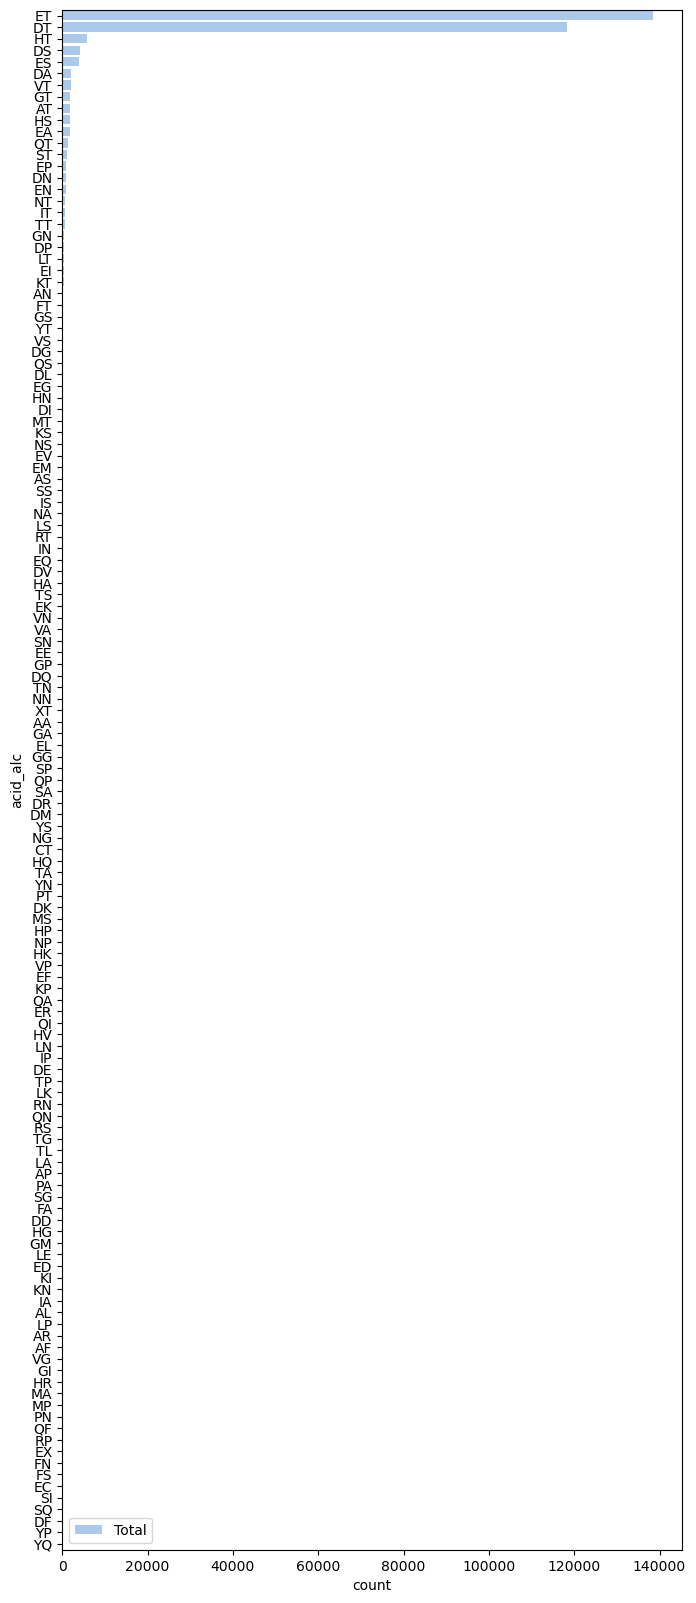

In [34]:
# Initialize the matplotlib figure
f, ax = plt.subplots(figsize=(8, 20))


sns.set_color_codes('pastel')
sns.barplot(x='count', 
            y='acid_alc', 
            data=count,
            label="Total", 
            color="b")

In [ ]:
sns.set_theme(style="whitegrid")

# Initialize the matplotlib figure
f, ax = plt.subplots(figsize=(6, 15))



NameError: name 'sns' is not defined